In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# 1. CARGA Y PREPARACIÓN
df = pd.read_csv(r'C:\Users\braya\Documents\TFM_UCM_Enagas\tfm_enagas\data\processed\df_modelado_sintomas.csv', index_col='datetime', parse_dates=True)
# Definir variables predictoras (X) - Solo Línea A
features = ['presion_in_A', 'temperatura_in_A', 'caudal_bruto_A', 
            'caudal_nominal_A', 'caudal_min_diario_A', 'caudal_max_diario_A', 'delta_presion_temp','is_anomaly',
       'tipo_fallo_detalle', 'is_scada_anomaly', 'tipo_fallo_scada', 'target_final_v2']
df=df[features]
df.shape

(105109, 12)

In [3]:
# Configurar para mostrar todas las filas
pd.set_option('display.max_rows', None)
# Configurar para mostrar todas las columnas
pd.set_option('display.max_columns', None)

df.head(3)

,presion_in_A,temperatura_in_A,caudal_bruto_A,caudal_nominal_A,caudal_min_diario_A,caudal_max_diario_A,delta_presion_temp,is_anomaly,tipo_fallo_detalle,is_scada_anomaly,tipo_fallo_scada,target_final_v2
datetime,,,,,,,,,,,,
2023-01-01 00:00:00,16.784145,11.613059,0.0,0.0,0,64135.745844,NaN,0,Normal,0,Normal,0
2023-01-01 00:05:00,16.760601,11.588407,0.0,0.0,0,64135.745844,0.023544,0,Normal,1,Pastilla desgastada,1
2023-01-01 00:10:00,16.730278,11.562312,0.0,0.0,0,64135.745844,0.030323,0,Normal,1,Pastilla desgastada,1


In [4]:
#df = df.fillna(0) # Limpiar el primer delta_presion que suele ser NaN
# Eliminar la Fila 1, porque tiene el Null en el Delta_presion
df = df.dropna(subset=['delta_presion_temp'])

In [5]:
# 2. CREACIÓN DE LAGS (SLIDING WINDOW)
columnas_fisicas = ['presion_in_A', 'temperatura_in_A', 'caudal_bruto_A', 'delta_presion_temp']
n_lags = 3 # Esto equivale a darle al modelo 15 minutos de "memoria" hacia atrás (3 x 5 min)

df_supervisado = df.copy()
for col in columnas_fisicas:
    for i in range(1, n_lags + 1):
        # Creamos una nueva columna desplazando los datos hacia abajo 'i' posiciones
        df_supervisado[f'{col}_lag{i}'] = df_supervisado[col].shift(i)

# Al hacer shift, las primeras 'n_lags' filas quedan con NaN, las borramos
df_supervisado = df_supervisado.dropna()

print(f"Dimensiones originales: {df.shape} | Dimensiones tabulares (supervisado): {df_supervisado.shape}")

Dimensiones originales: (105108, 12) | Dimensiones tabulares (supervisado): (105105, 24)


In [6]:
# 3. PREPARACIÓN DE VARIABLES PARA RANDOM FOREST 
# Recolectamos dinámicamente las columnas originales + los lags recién creados
features = columnas_fisicas + [col for col in df_supervisado.columns if 'lag' in col]
X = df_supervisado[features]

# Definimos el target físico
y = df_supervisado['is_scada_anomaly'] 

# División única para que todos compitan bajo las mismas condiciones
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
X.head()

,presion_in_A,temperatura_in_A,caudal_bruto_A,delta_presion_temp,presion_in_A_lag1,presion_in_A_lag2,presion_in_A_lag3,temperatura_in_A_lag1,temperatura_in_A_lag2,temperatura_in_A_lag3,caudal_bruto_A_lag1,caudal_bruto_A_lag2,caudal_bruto_A_lag3,delta_presion_temp_lag1,delta_presion_temp_lag2,delta_presion_temp_lag3
datetime,,,,,,,,,,,,,,,,
2023-01-01 00:20:00,16.740030,11.522590,0.0,0.019039,16.720991,16.730278,16.760601,11.533041,11.562312,11.588407,0.0,0.0,0.0,0.009287,0.030323,0.023544
2023-01-01 00:25:00,16.765572,11.530180,0.0,0.025541,16.740030,16.720991,16.730278,11.522590,11.533041,11.562312,0.0,0.0,0.0,0.019039,0.009287,0.030323
2023-01-01 00:30:00,16.787861,11.536973,0.0,0.022289,16.765572,16.740030,16.720991,11.530180,11.522590,11.533041,0.0,0.0,0.0,0.025541,0.019039,0.009287
2023-01-01 00:35:00,16.789719,11.523055,0.0,0.001858,16.787861,16.765572,16.740030,11.536973,11.530180,11.522590,0.0,0.0,0.0,0.022289,0.025541,0.019039
2023-01-01 00:40:00,16.795073,11.501480,0.0,0.005354,16.789719,16.787861,16.765572,11.523055,11.536973,11.530180,0.0,0.0,0.0,0.001858,0.022289,0.025541


In [8]:
y.head()

datetime
2023-01-01 00:20:00    1
2023-01-01 00:25:00    1
2023-01-01 00:30:00    1
2023-01-01 00:35:00    0
2023-01-01 00:40:00    0
Name: is_scada_anomaly, dtype: int64

In [9]:
def entrenar_rf(X_train, X_test, y_train, y_test, titulo):
    """
    Entrena un Random Forest usando los sets ya divididos.
    """
    # Usamos class_weight='balanced' para compensar que hay pocos síntomas vs datos normales
    model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n{'='*40}")
    print(f"--- PERFORMANCE: {titulo} ---")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred))
    
    return model, y_pred

In [10]:
from xgboost import XGBClassifier

def entrenar_xgboost(X_train, X_test, y_train, y_test):
    # Calculamos el peso para balancear la clase minoritaria
    ratio = (len(y_train) - sum(y_train)) / sum(y_train)
    
    model = XGBClassifier(n_estimators=100, scale_pos_weight=ratio, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print("\n--- PERFORMANCE: XGBOOST ---")
    print(classification_report(y_test, y_pred))
    return model, y_pred

In [11]:
from sklearn.svm import SVC

def entrenar_svm(X_train, X_test, y_train, y_test):
    # 'balanced' ajusta pesos automáticamente según la frecuencia de clase
    model = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print("\n--- PERFORMANCE: SVM ---")
    print(classification_report(y_test, y_pred))
    return model, y_pred

In [12]:
from sklearn.neural_network import MLPClassifier

def entrenar_mlp_nn(X_train, X_test, y_train, y_test):
    # Arquitectura de 2 capas ocultas
    model = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', 
                          max_iter=500, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print("\n--- PERFORMANCE: MULTI-LAYER PERCEPTRON (NN) ---")
    print(classification_report(y_test, y_pred))
    return model, y_pred

**PARTE 1: Comparativa SAP vs. SCADA**

Aquí usamos el mismo modelo (Random Forest) para exponer la diferencia de calidad entre los datos de gestión y los físicos.


--- PERFORMANCE: SÍNTOMAS SAP (Gestión) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20963
           1       0.88      0.12      0.21        58

    accuracy                           1.00     21021
   macro avg       0.94      0.56      0.61     21021
weighted avg       1.00      1.00      1.00     21021


--- PERFORMANCE: SÍNTOMAS SCADA (Física) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19390
           1       1.00      1.00      1.00      1631

    accuracy                           1.00     21021
   macro avg       1.00      1.00      1.00     21021
weighted avg       1.00      1.00      1.00     21021



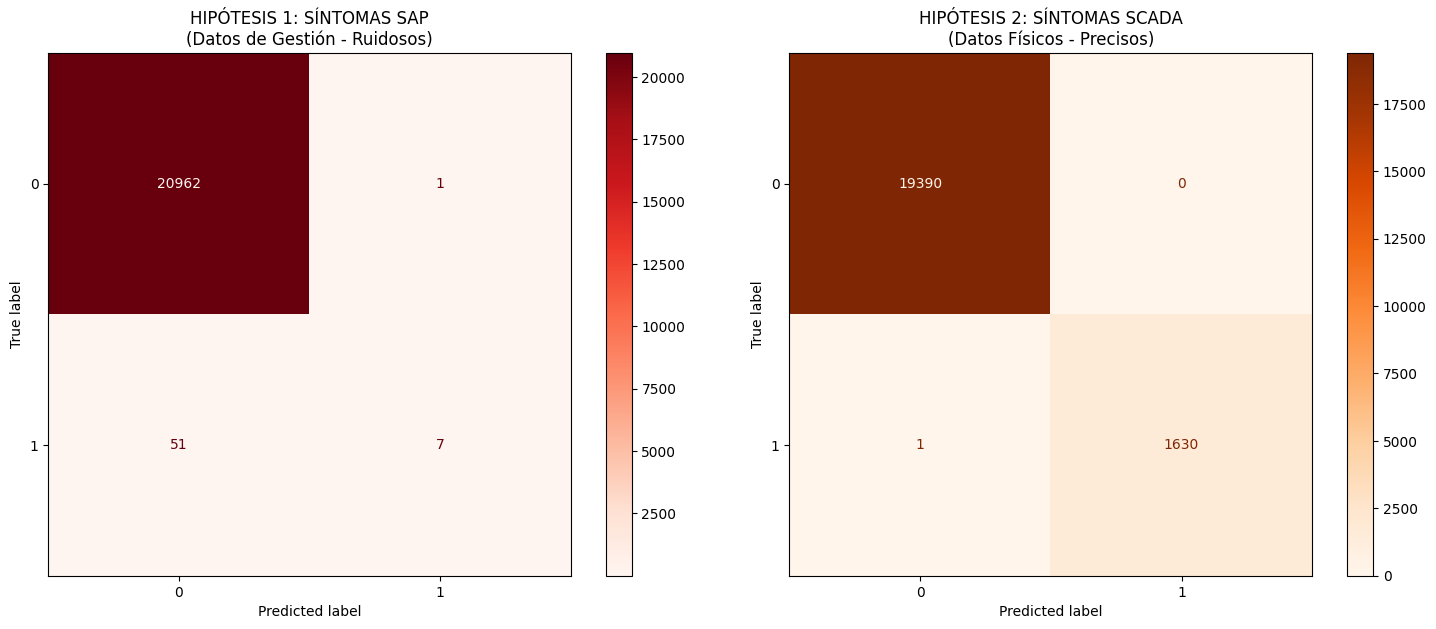

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

# --- A. Entrenar para SAP ---
y_sap = df_supervisado['is_anomaly']
X_train_sap, X_test_sap, y_train_sap, y_test_sap = train_test_split(X, y_sap, test_size=0.2, random_state=42, stratify=y_sap)
model_sap, pred_sap = entrenar_rf(X_train_sap, X_test_sap, y_train_sap, y_test_sap, "SÍNTOMAS SAP (Gestión)")

# --- B. Entrenar para SCADA ---
y_scada = df_supervisado['is_scada_anomaly']
X_train_scada, X_test_scada, y_train_scada, y_test_scada = train_test_split(X, y_scada, test_size=0.2, random_state=42, stratify=y_scada)
model_scada, pred_scada = entrenar_rf(X_train_scada, X_test_scada, y_train_scada, y_test_scada, "SÍNTOMAS SCADA (Física)")

# --- C. Visualización Comparativa de Hipótesis ---
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ConfusionMatrixDisplay.from_predictions(y_test_sap, pred_sap, ax=ax[0], cmap='Reds')
ax[0].set_title('HIPÓTESIS 1: SÍNTOMAS SAP\n(Datos de Gestión - Ruidosos)')

ConfusionMatrixDisplay.from_predictions(y_test_scada, pred_scada, ax=ax[1], cmap='Oranges')
ax[1].set_title('HIPÓTESIS 2: SÍNTOMAS SCADA\n(Datos Físicos - Precisos)')

plt.tight_layout()
plt.show()

**PARTE 2: Competencia de Modelos (Selección de la Herramienta)**

Ahora que los resultados de arriba te dirán que "SCADA es el camino", procedes a optimizar la detección física con los otros modelos que creamos.

In [ ]:
# Trabajamos sobre los datos de SCADA (los mejores)
# X_train_scada, X_test_scada, etc. ya están definidos arriba
print("\n" + "="*50)
print("INICIO DE COMPETENCIA DE MODELOS (TARGET: SCADA)")
print("="*50)
# Ejecutar modelos
model_rf, pred_rf = entrenar_rf(X_train_scada, X_test_scada, y_train_scada, y_test_scada, "SÍNTOMAS DE FALLO" )
model_xgb, pred_xgb = entrenar_xgboost(X_train_scada, X_test_scada, y_train_scada, y_test_scada)
model_svm, pred_svm = entrenar_svm(X_train_scada, X_test_scada, y_train_scada, y_test_scada)
model_nn, pred_nn = entrenar_mlp_nn(X_train_scada, X_test_scada, y_train_scada, y_test_scada)


INICIO DE COMPETENCIA DE MODELOS (TARGET: SCADA)

--- PERFORMANCE: SÍNTOMAS DE FALLO ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19390
           1       1.00      1.00      1.00      1631

    accuracy                           1.00     21021
   macro avg       1.00      1.00      1.00     21021
weighted avg       1.00      1.00      1.00     21021


--- PERFORMANCE: XGBOOST ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19390
           1       0.99      1.00      0.99      1631

    accuracy                           1.00     21021
   macro avg       0.99      1.00      1.00     21021
weighted avg       1.00      1.00      1.00     21021

